In [ ]:
# Cell 1 — Install Dependencies
!pip install -q kaggle kagglehub opencv-python-headless matplotlib tensorflow scikit-learn scikit-image seaborn

In [ ]:
# Cell 2 — Download Dataset
import kagglehub

path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
print('Dataset downloaded to:', path)

import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]:
            print(f'{indent}  {f}')

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
brain-tumor-mri-dataset/
  Training/
    pituitary/
      Tr-pi_124.jpg
      Tr-pi_949.jpg
      Tr-pi_786.jpg
    notumor/
      Tr-no_323.jpg
      Tr-no_86.jpg
      Tr-no_737.jpg
    meningioma/
      Tr-me_166.jpg
      Tr-me_1256.jpg
      Tr-me_115.jpg
    glioma/
      Tr-gl_1362.jpg
      Tr-gl_821.jpg
      Tr-gl_825.jpg
  Testing/
    pituitary/
      Te-pi_307.jpg
      Te-pi_269.jpg
      Te-pi_63.jpg
    notumor/
      Te-no_39.jpg
      Te-no_46.jpg
      Te-no_340.jpg
    meningioma/
      Te-me_251.jpg
      Te-me_175.jpg
      Te-me_60.jpg
    glioma/
      Te-gl_16.jpg
      Te-gl_87.jpg
      Te-gl_392.jpg


In [ ]:
# Cell 3 — Organise Dataset
import os, shutil, random
from pathlib import Path

BASE_DIR   = Path(path)
TRAIN_DIR  = Path('/content/dataset/train')
TEST_DIR   = Path('/content/dataset/test')
SPLIT      = 0.8
random.seed(42)

# The dataset has Training/ and Testing/ folders with 4 classes
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Try to find Training folder
train_src = None
test_src  = None
for candidate in ['Training', 'training', 'train']:
    p = BASE_DIR / candidate
    if p.exists():
        train_src = p
        break
    found = list(BASE_DIR.rglob(candidate))
    if found:
        train_src = found[0]
        break

for candidate in ['Testing', 'testing', 'test']:
    p = BASE_DIR / candidate
    if p.exists():
        test_src = p
        break
    found = list(BASE_DIR.rglob(candidate))
    if found:
        test_src = found[0]
        break

print(f'Train source: {train_src}')
print(f'Test  source: {test_src}')

# Detect actual class names from folder
if train_src and train_src.exists():
    found_classes = [d.name for d in train_src.iterdir() if d.is_dir()]
    print('Classes found:', found_classes)
    CLASSES = found_classes

def copy_split(src_root, classes, train_dir, test_dir, split=0.8):
    for cls in classes:
        src = src_root / cls
        if not src.exists():
            print(f'  WARNING: {src} not found, skipping'); continue
        imgs = list(src.glob('*.jpg')) + list(src.glob('*.png')) + list(src.glob('*.jpeg'))
        random.shuffle(imgs)
        cut = int(len(imgs) * split)
        for subset, chunk in [('train', imgs[:cut]), ('test', imgs[cut:])]:
            dest = Path(f'/content/dataset/{subset}/{cls}')
            dest.mkdir(parents=True, exist_ok=True)
            for img in chunk:
                shutil.copy(img, dest / img.name)
        print(f'  {cls}: {cut} train | {len(imgs)-cut} test')

if train_src and test_src:
    # Dataset already split — copy as-is
    print('\nCopying pre-split dataset...')
    for cls in CLASSES:
        for subset, src_root in [('train', train_src), ('test', test_src)]:
            src = src_root / cls
            if not src.exists(): continue
            dest = Path(f'/content/dataset/{subset}/{cls}')
            dest.mkdir(parents=True, exist_ok=True)
            imgs = list(src.glob('*.jpg')) + list(src.glob('*.png')) + list(src.glob('*.jpeg'))
            for img in imgs:
                shutil.copy(img, dest / img.name)
        count_tr = len(list((Path(f'/content/dataset/train/{cls}')).glob('*')))
        count_te = len(list((Path(f'/content/dataset/test/{cls}')).glob('*')))
        print(f'  {cls}: {count_tr} train | {count_te} test')
elif train_src:
    print('\nSplitting training folder 80/20...')
    copy_split(train_src, CLASSES, TRAIN_DIR, TEST_DIR, split=SPLIT)
else:
    print('Could not locate dataset folders. Please check path manually.')

print('\nDataset organised at /content/dataset/')

Train source: /kaggle/input/brain-tumor-mri-dataset/Training
Test  source: /kaggle/input/brain-tumor-mri-dataset/Testing
Classes found: ['pituitary', 'notumor', 'meningioma', 'glioma']

Copying pre-split dataset...
  pituitary: 1400 train | 400 test
  notumor: 1400 train | 400 test
  meningioma: 1400 train | 400 test
  glioma: 1400 train | 400 test

Dataset organised at /content/dataset/


In [ ]:
# Cell 4 — Imports & GPU Check
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import random, warnings
warnings.filterwarnings('ignore')

from skimage.segmentation import flood_fill
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
print('GPUs:', gpus if gpus else 'None — running on CPU')

CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = (128, 128)
DATASET_DIR = Path('/content/dataset')

# Verify classes actually exist
found = [d.name for d in (DATASET_DIR / 'train').iterdir() if d.is_dir()]
CLASSES = sorted(found)
NUM_CLASSES = len(CLASSES)
print(f'\nClasses ({NUM_CLASSES}):', CLASSES)

TensorFlow: 2.20.0
GPUs: None — running on CPU

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


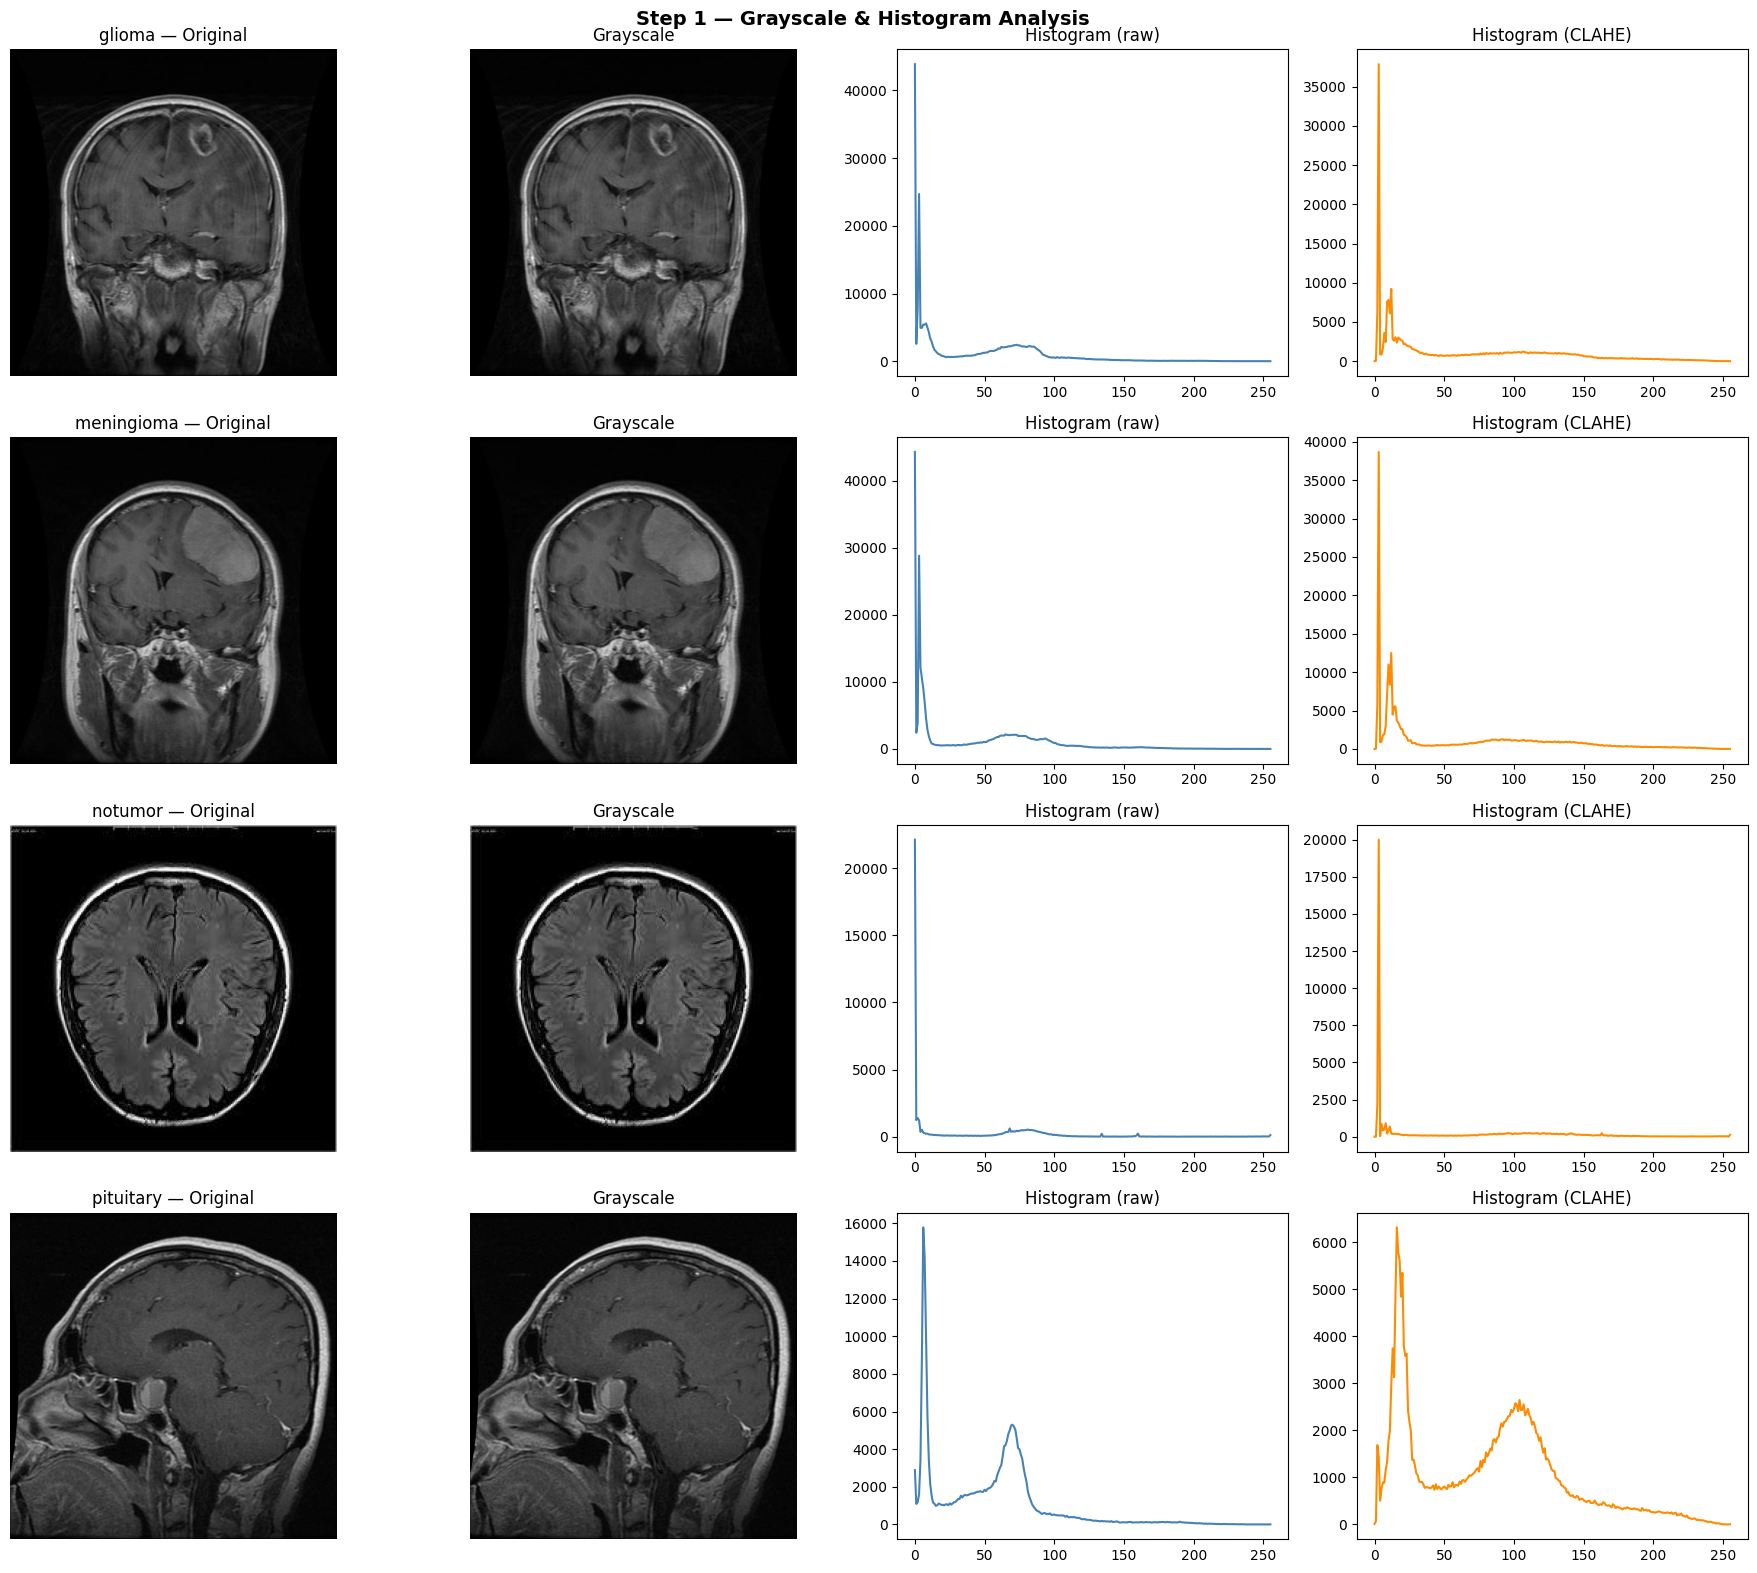

In [ ]:
# Cell 5 — Grayscale + Histogram

def to_grayscale(bgr):
    """Convert BGR image to grayscale."""
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

def equalize_histogram(gray):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

def plot_histogram(gray, title='Histogram'):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    plt.figure(figsize=(6, 3))
    plt.plot(hist, color='steelblue')
    plt.title(title); plt.xlabel('Pixel Intensity'); plt.ylabel('Count')
    plt.tight_layout(); plt.show()

# ── Demo on one sample from each class ───────────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(18, 4 * len(CLASSES)))
if len(CLASSES) == 1:
    axes = [axes]

for row, cls in enumerate(CLASSES):
    img_paths = list((DATASET_DIR / 'train' / cls).glob('*.jpg'))[:1
    ] + list((DATASET_DIR / 'train' / cls).glob('*.png'))[:1]
    if not img_paths: continue
    bgr  = cv2.imread(str(img_paths[0]))
    gray = to_grayscale(bgr)
    eq   = equalize_histogram(gray)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    hist_eq = cv2.calcHist([eq], [0], None, [256], [0, 256]).flatten()

    axes[row][0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); axes[row][0].set_title(f'{cls} — Original')
    axes[row][1].imshow(gray, cmap='gray');                     axes[row][1].set_title('Grayscale')
    axes[row][2].plot(hist, color='steelblue');                  axes[row][2].set_title('Histogram (raw)')
    axes[row][3].plot(hist_eq, color='darkorange');              axes[row][3].set_title('Histogram (CLAHE)')
    for ax in axes[row]: ax.axis('off') if ax.get_images() or ax.patches else None

plt.suptitle('Step 1 — Grayscale & Histogram Analysis', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

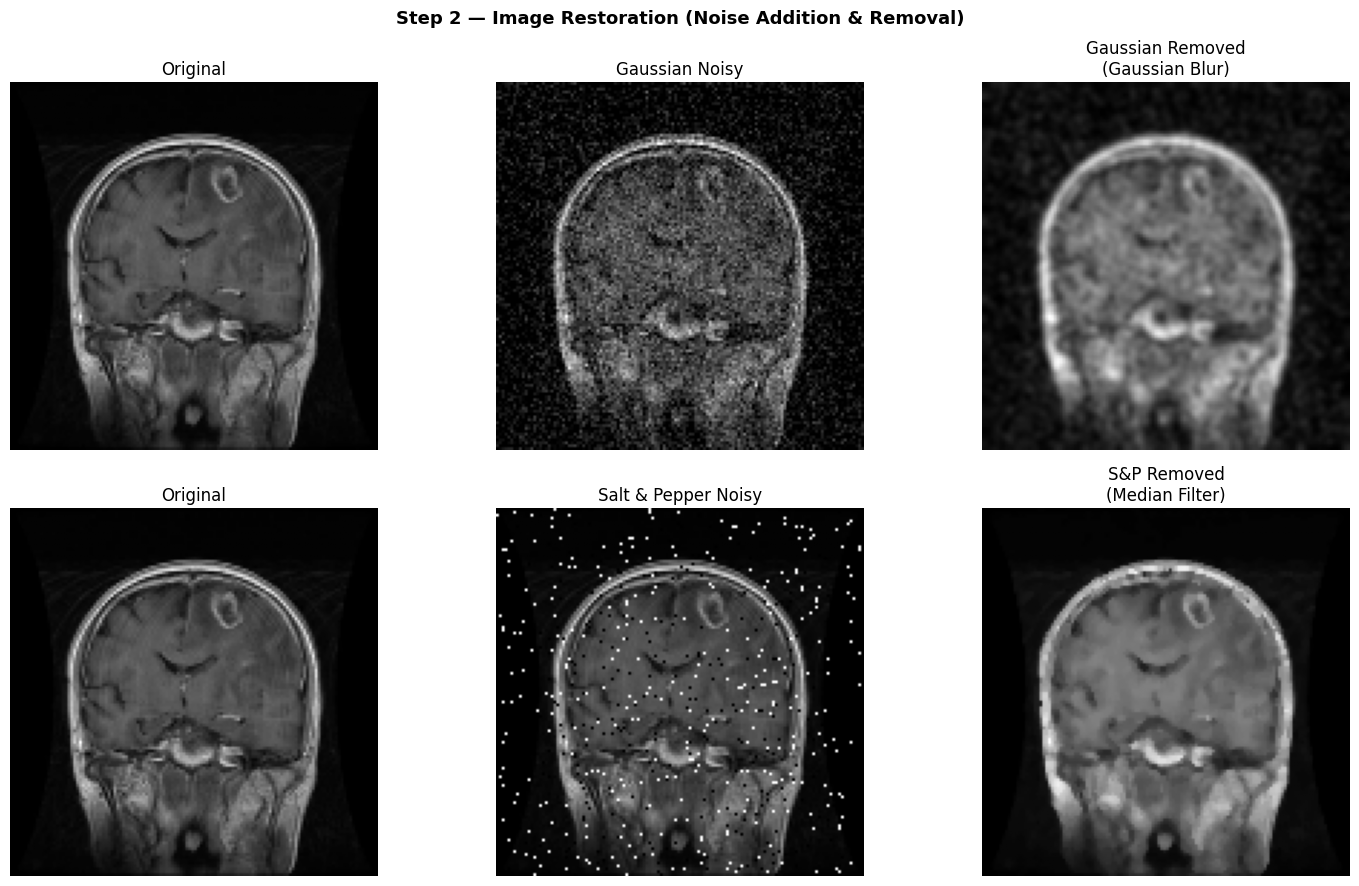

In [ ]:
# Cell 6 — Image Restoration

def add_gaussian_noise(gray, mean=0, sigma=25):
    """Add Gaussian noise to a grayscale image."""
    noise = np.random.normal(mean, sigma, gray.shape).astype(np.float32)
    noisy = np.clip(gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

def remove_gaussian_noise(noisy, ksize=5):
    """Remove Gaussian noise using Gaussian blur."""
    return cv2.GaussianBlur(noisy, (ksize, ksize), 0)

def add_salt_pepper_noise(gray, amount=0.02):
    """Add salt-and-pepper noise to a grayscale image."""
    noisy = gray.copy()
    n_pixels = int(amount * gray.size)
    # Salt
    coords = [np.random.randint(0, d, n_pixels) for d in gray.shape]
    noisy[coords[0], coords[1]] = 255
    # Pepper
    coords = [np.random.randint(0, d, n_pixels) for d in gray.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

def remove_salt_pepper_noise(noisy, ksize=3):
    """Remove salt-and-pepper noise using Median filter."""
    return cv2.medianBlur(noisy, ksize)

# ── Demo ─────────────────────────────────────────────────────────────────────
sample_cls = CLASSES[0]
sample_img_path = list((DATASET_DIR / 'train' / sample_cls).glob('*.jpg'))[0]
bgr_sample = cv2.imread(str(sample_img_path))
gray_sample = to_grayscale(bgr_sample)
gray_sample = cv2.resize(gray_sample, IMG_SIZE)

g_noisy   = add_gaussian_noise(gray_sample)
g_removed = remove_gaussian_noise(g_noisy)

sp_noisy   = add_salt_pepper_noise(gray_sample)
sp_removed = remove_salt_pepper_noise(sp_noisy)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [
    (gray_sample, 'Original'),
    (g_noisy,     'Gaussian Noisy'),
    (g_removed,   'Gaussian Removed\n(Gaussian Blur)'),
    (gray_sample, 'Original'),
    (sp_noisy,    'Salt & Pepper Noisy'),
    (sp_removed,  'S&P Removed\n(Median Filter)'),
]
for ax, (img, ttl) in zip(axes.flat, pairs):
    ax.imshow(img, cmap='gray'); ax.set_title(ttl); ax.axis('off')

plt.suptitle('Step 2 — Image Restoration (Noise Addition & Removal)', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

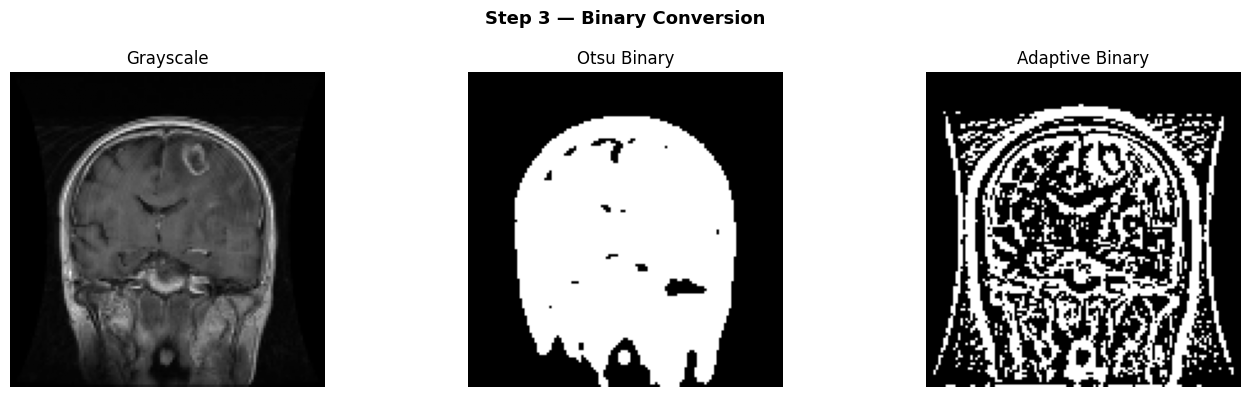

Otsu threshold auto-selected for this image.


In [ ]:
# Cell 7 — Binary Thresholding

def to_binary_otsu(gray):
    """
    Convert grayscale to binary using Otsu's automatic thresholding.
    Returns binary mask (0 or 255).
    """
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary

def to_binary_adaptive(gray):
    """
    Adaptive thresholding — handles uneven illumination better.
    """
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

# ── Demo ─────────────────────────────────────────────────────────────────────
bin_otsu  = to_binary_otsu(gray_sample)
bin_adapt = to_binary_adaptive(gray_sample)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray_sample,  cmap='gray'); axes[0].set_title('Grayscale')
axes[1].imshow(bin_otsu,     cmap='gray'); axes[1].set_title('Otsu Binary')
axes[2].imshow(bin_adapt,    cmap='gray'); axes[2].set_title('Adaptive Binary')
for ax in axes: ax.axis('off')
plt.suptitle('Step 3 — Binary Conversion', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()
print(f'Otsu threshold auto-selected for this image.')

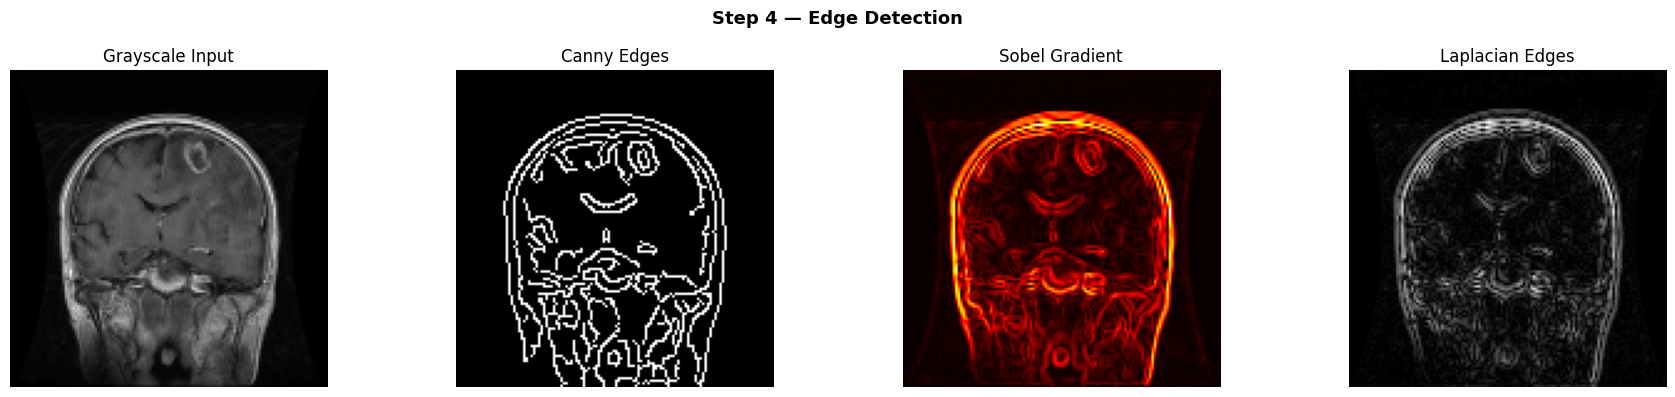

In [ ]:
# Cell 8 — Edge Detection (Canny + Sobel)

def edge_detection_canny(gray, low=30, high=100):
    """Canny edge detector on preprocessed grayscale image."""
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.Canny(blurred, low, high)

def edge_detection_sobel(gray):
    """Sobel gradient edge detection."""
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = np.uint8(np.clip(magnitude / magnitude.max() * 255, 0, 255))
    return magnitude

def edge_detection_laplacian(gray):
    """Laplacian edge detection."""
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    lap = cv2.Laplacian(blurred, cv2.CV_64F)
    lap = np.uint8(np.clip(np.abs(lap) / np.abs(lap).max() * 255, 0, 255))
    return lap

# ── Demo ─────────────────────────────────────────────────────────────────────
canny_edges   = edge_detection_canny(gray_sample)
sobel_edges   = edge_detection_sobel(gray_sample)
laplace_edges = edge_detection_laplacian(gray_sample)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(gray_sample,    cmap='gray');  axes[0].set_title('Grayscale Input')
axes[1].imshow(canny_edges,    cmap='gray');  axes[1].set_title('Canny Edges')
axes[2].imshow(sobel_edges,    cmap='hot');   axes[2].set_title('Sobel Gradient')
axes[3].imshow(laplace_edges,  cmap='gray');  axes[3].set_title('Laplacian Edges')
for ax in axes: ax.axis('off')
plt.suptitle('Step 4 — Edge Detection', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

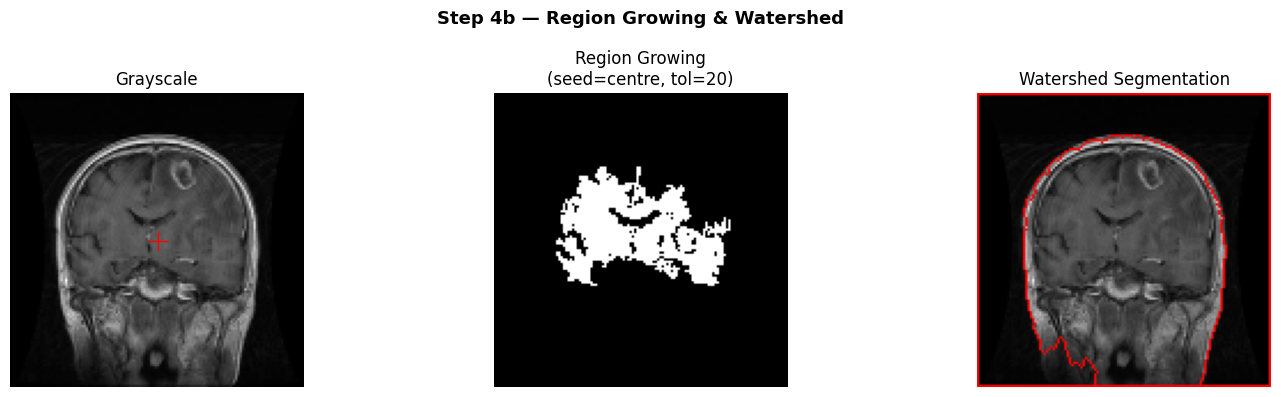

In [ ]:
# Cell 9 — Region Growing Segmentation

def region_growing(gray, seed_point=None, tolerance=15):
    """
    Simple region growing from a seed point.
    Grows into neighbouring pixels within `tolerance` of seed intensity.
    Returns a binary mask of the grown region.
    """
    h, w = gray.shape
    if seed_point is None:
        seed_point = (h // 2, w // 2)   # centre of image as default seed

    seed_val = int(gray[seed_point[0], seed_point[1]])
    visited  = np.zeros((h, w), dtype=bool)
    region   = np.zeros((h, w), dtype=np.uint8)

    stack = [seed_point]
    while stack:
        r, c = stack.pop()
        if r < 0 or r >= h or c < 0 or c >= w:
            continue
        if visited[r, c]:
            continue
        visited[r, c] = True
        pixel_val = int(gray[r, c])
        if abs(pixel_val - seed_val) <= tolerance:
            region[r, c] = 255
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                stack.append((r + dr, c + dc))
    return region

def watershed_segment(bgr):
    """
    Marker-based watershed segmentation.
    Returns coloured label image.
    """
    gray_ws = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray_ws = cv2.resize(gray_ws, IMG_SIZE)
    bgr_ws  = cv2.resize(bgr,     IMG_SIZE)

    # Threshold to get foreground seeds
    _, thresh = cv2.threshold(gray_ws, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opening   = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    sure_bg   = cv2.dilate(opening, kernel, iterations=3)
    dist_map  = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_map, 0.4 * dist_map.max(), 255, 0)
    sure_fg   = sure_fg.astype(np.uint8)
    unknown   = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers    = markers + 1
    markers[unknown == 255] = 0

    bgr_ws3 = cv2.cvtColor(gray_ws, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(bgr_ws3, markers)
    result  = bgr_ws3.copy()
    result[markers == -1] = [0, 0, 255]   # boundaries in red
    return result

# ── Demo ─────────────────────────────────────────────────────────────────────
rg_mask    = region_growing(gray_sample, seed_point=(64, 64), tolerance=20)
ws_result  = watershed_segment(bgr_sample)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray_sample, cmap='gray');            axes[0].set_title('Grayscale')
axes[0].plot(64, 64, 'r+', markersize=15)            # seed point
axes[1].imshow(rg_mask,     cmap='gray');            axes[1].set_title('Region Growing\n(seed=centre, tol=20)')
axes[2].imshow(cv2.cvtColor(ws_result, cv2.COLOR_BGR2RGB)); axes[2].set_title('Watershed Segmentation')
for ax in axes: ax.axis('off')
plt.suptitle('Step 4b — Region Growing & Watershed', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

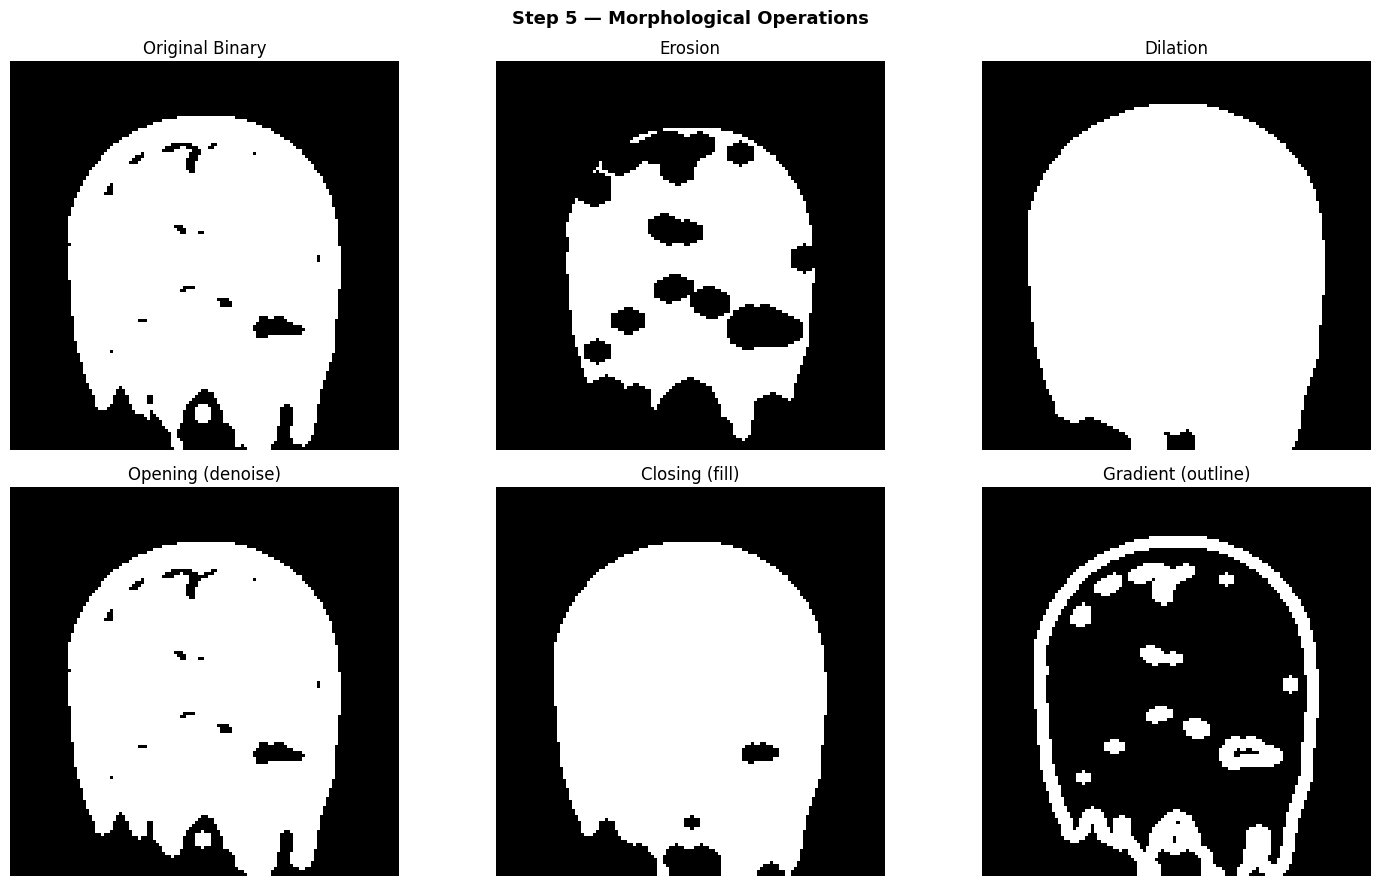

In [ ]:
# Cell 10 — Morphological Operations

def morphological_ops(binary):
    """
    Apply erosion, dilation, opening, and closing.
    Returns dict of results.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return {
        'original':  binary,
        'erosion':   cv2.erode(binary, kernel, iterations=2),
        'dilation':  cv2.dilate(binary, kernel, iterations=2),
        'opening':   cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel),   # erosion then dilation  — removes noise
        'closing':   cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel),   # dilation then erosion  — fills holes
        'gradient':  cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel), # dilation - erosion = outline
    }

morph = morphological_ops(bin_otsu)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
labels = ['Original Binary', 'Erosion', 'Dilation', 'Opening (denoise)', 'Closing (fill)', 'Gradient (outline)']
keys   = ['original', 'erosion', 'dilation', 'opening', 'closing', 'gradient']
for ax, key, lbl in zip(axes.flat, keys, labels):
    ax.imshow(morph[key], cmap='gray')
    ax.set_title(lbl); ax.axis('off')

plt.suptitle('Step 5 — Morphological Operations', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

=== BOUNDARY DESCRIPTORS (top 3 contours) ===
  Area=7886  Perim=386.7  Aspect=0.818  Solidity=0.947  Circularity=0.663

=== REGION DESCRIPTORS (top 3 regions) ===
  Region 1: Area=7981.0  Centroid=(np.float64(71.0), np.float64(64.2))  MeanIntensity=77.25  Eccentricity=0.547


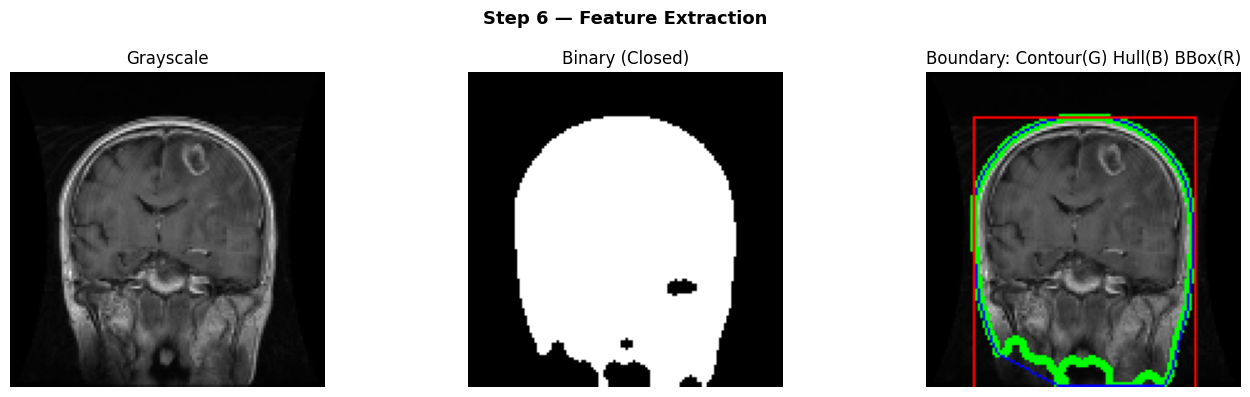

In [ ]:
# Cell 11 — Feature Extraction

def extract_boundary_descriptors(binary):
    """
    Boundary Descriptors:
    - Contour perimeter
    - Bounding box
    - Convex hull area
    - Aspect ratio, extent, solidity
    Returns: list of dicts, one per contour
    """
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    results = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 100: continue
        perim = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)
        hull_area  = cv2.contourArea(cv2.convexHull(cnt))
        aspect     = w / h if h > 0 else 0
        extent     = area / (w * h) if w * h > 0 else 0
        solidity   = area / hull_area if hull_area > 0 else 0
        circularity = (4 * np.pi * area / (perim ** 2)) if perim > 0 else 0
        results.append({
            'area': area, 'perimeter': perim,
            'bounding_box': (x, y, w, h),
            'aspect_ratio': round(aspect, 3),
            'extent': round(extent, 3),
            'solidity': round(solidity, 3),
            'circularity': round(circularity, 3),
        })
    return sorted(results, key=lambda r: r['area'], reverse=True)

def extract_region_descriptors(gray, binary):
    """
    Region Descriptors using skimage regionprops:
    - Mean intensity, std, centroid
    - Major/minor axis length
    - Eccentricity, orientation
    """
    labeled = label(binary > 127)
    props   = regionprops(labeled, intensity_image=gray)
    results = []
    for p in props:
        if p.area < 100: continue
        results.append({
            'label':          p.label,
            'area':           p.area,
            'centroid':       tuple(round(c, 1) for c in p.centroid),
            'mean_intensity': round(p.mean_intensity, 2),
            'major_axis':     round(p.major_axis_length, 2),
            'minor_axis':     round(p.minor_axis_length, 2),
            'eccentricity':   round(p.eccentricity, 3),
            'orientation':    round(np.degrees(p.orientation), 2),
        })
    return sorted(results, key=lambda r: r['area'], reverse=True)

# ── Demo ─────────────────────────────────────────────────────────────────────
cleaned  = morph['closing']    # use morphologically cleaned binary
boundary = extract_boundary_descriptors(cleaned)
region   = extract_region_descriptors(gray_sample, cleaned)

print(f'=== BOUNDARY DESCRIPTORS (top 3 contours) ===')
for d in boundary[:3]:
    print(f"  Area={d['area']:.0f}  Perim={d['perimeter']:.1f}  "
          f"Aspect={d['aspect_ratio']}  Solidity={d['solidity']}  Circularity={d['circularity']}")

print(f'\n=== REGION DESCRIPTORS (top 3 regions) ===')
for d in region[:3]:
    print(f"  Region {d['label']}: Area={d['area']}  Centroid={d['centroid']}  "
          f"MeanIntensity={d['mean_intensity']}  Eccentricity={d['eccentricity']}")

# Visualise largest contour
vis = cv2.cvtColor(gray_sample, cv2.COLOR_GRAY2BGR)
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
if contours_sorted:
    cv2.drawContours(vis, [contours_sorted[0]], -1, (0, 255, 0), 2)
    hull = cv2.convexHull(contours_sorted[0])
    cv2.drawContours(vis, [hull], -1, (255, 0, 0), 1)
    x, y, w, h = cv2.boundingRect(contours_sorted[0])
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,0,255), 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray_sample, cmap='gray'); axes[0].set_title('Grayscale')
axes[1].imshow(cleaned,     cmap='gray'); axes[1].set_title('Binary (Closed)')
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[2].set_title('Boundary: Contour(G) Hull(B) BBox(R)')
for ax in axes: ax.axis('off')
plt.suptitle('Step 6 — Feature Extraction', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Cell 12 — Full Preprocessing Pipeline

def full_preprocess(image_bgr, target_size=IMG_SIZE):
    """
    Full preprocessing pipeline for CNN input:
      1. Resize
      2. Grayscale
      3. Median filter (remove S&P noise)
      4. CLAHE histogram equalization
      5. Gaussian blur (smooth)
      6. Normalize to [0, 1]
    Returns: float32 array (H, W, 1)
    """
    img = cv2.resize(image_bgr, target_size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.medianBlur(gray, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(denoised)
    smoothed = cv2.GaussianBlur(equalized, (3, 3), 0)
    normalized = smoothed.astype(np.float32) / 255.0
    return normalized[..., np.newaxis]   # shape (H, W, 1)

# Quick sanity check
test_proc = full_preprocess(bgr_sample)
print(f'Preprocessed shape: {test_proc.shape}, dtype: {test_proc.dtype}')
print(f'Min: {test_proc.min():.3f}, Max: {test_proc.max():.3f}')

Preprocessed shape: (128, 128, 1), dtype: float32
Min: 0.008, Max: 0.957


Loading TRAIN set...
  [train] glioma: 1400 images loaded
  [train] meningioma: 1400 images loaded
  [train] notumor: 1400 images loaded
  [train] pituitary: 1400 images loaded
  → Shape: (5600, 128, 128, 1)

Loading TEST set...
  [test] glioma: 400 images loaded
  [test] meningioma: 400 images loaded
  [test] notumor: 400 images loaded
  [test] pituitary: 400 images loaded
  → Shape: (1600, 128, 128, 1)

Train: (4760, 128, 128, 1) | Val: (840, 128, 128, 1) | Test: (1600, 128, 128, 1)


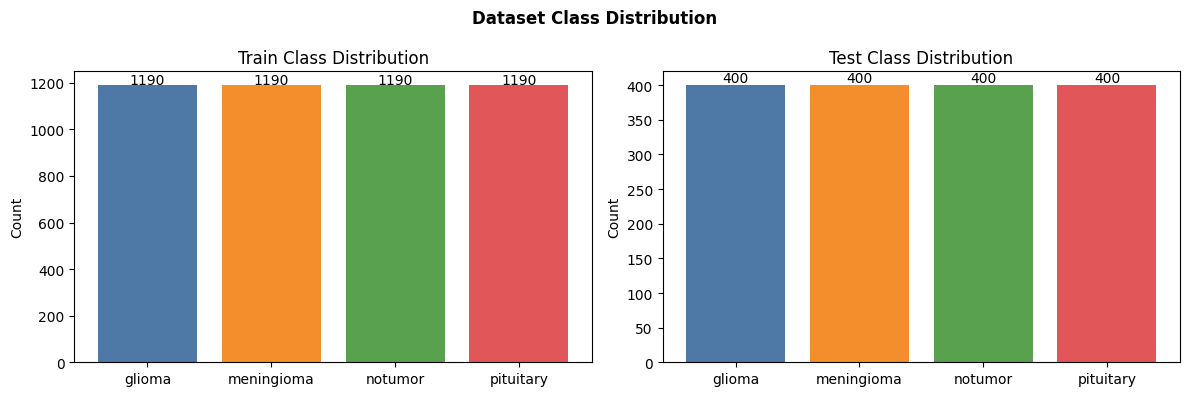

In [ ]:
# Cell 13 — Load Dataset
from tqdm.auto import tqdm

def load_dataset(split='train', max_per_class=None):
    """
    Load all images from /content/dataset/{split}/{class}/ folders.
    Returns X (N, H, W, 1) float32, y (N,) int
    """
    X, y = [], []
    split_dir = DATASET_DIR / split
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            print(f'  WARNING: {cls_dir} not found')
            continue
        imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.jpeg'))
        if max_per_class:
            imgs = imgs[:max_per_class]
        for img_path in imgs:
            bgr = cv2.imread(str(img_path))
            if bgr is None: continue
            processed = full_preprocess(bgr)
            X.append(processed)
            y.append(cls_idx)
        print(f'  [{split}] {cls_name}: {len(imgs)} images loaded')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading TRAIN set...')
X_train_full, y_train_full = load_dataset('train')
print(f'  → Shape: {X_train_full.shape}')

print('\nLoading TEST set...')
X_test, y_test = load_dataset('test')
print(f'  → Shape: {X_test.shape}')

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)
print(f'\nTrain: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (yy, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = [np.sum(yy == i) for i in range(NUM_CLASSES)]
    ax.bar(CLASSES, counts, color=['#4e79a7','#f28e2b','#59a14f','#e15759'])
    ax.set_title(f'{title} Class Distribution'); ax.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax.text(i, c + 5, str(c), ha='center', fontsize=10)
plt.suptitle('Dataset Class Distribution', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Cell 14 — Build CNN Model (Simple, no frills)

def build_model(input_shape=(128, 128, 1), num_classes=4):
    """
    Simple CNN:
    3 x [Conv2D -> BN -> ReLU -> MaxPool]
    Flatten -> Dense(128) -> Dropout -> Dense(num_classes, softmax)
    """
    model = models.Sequential(name='BrainTumor_CNN', layers=[
        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(input_shape=(*IMG_SIZE, 1), num_classes=NUM_CLASSES)
model.summary()

Model: "BrainTumor_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,516 (16.36 MB)

 Trainable params: 4,288,068 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Cell 15 — Mount Drive + Load or Train

from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf
from tensorflow.keras import models, callbacks

# New model path
DRIVE_MODEL_PATH = '/content/best_brain_tumor_model_claude.keras'

# Check model exists or not
if os.path.exists(DRIVE_MODEL_PATH):

    print(f'✅ Found saved model at: {DRIVE_MODEL_PATH}')
    print('Loading existing model...')

    model = models.load_model(DRIVE_MODEL_PATH)

    print('✅ Model loaded successfully!')

    SKIP_TRAINING = True

else:

    print(f'❌ No saved model found at: {DRIVE_MODEL_PATH}')
    print('Training will start from scratch.')

    SKIP_TRAINING = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
❌ No saved model found at: /content/best_brain_tumor_model_claude.keras
Training will start from scratch.


In [ ]:
if SKIP_TRAINING:

    print('✅ Skipping training — model already loaded.')

else:

    EPOCHS = 10
    BATCH_SIZE = 32

    cb_early = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    cb_reduce = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )

    # Save best model
    cb_ckpt = callbacks.ModelCheckpoint(
        DRIVE_MODEL_PATH,
        save_best_only=True,
        verbose=1
    )

    print(f'Training model for {EPOCHS} epochs...')

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[cb_early, cb_reduce, cb_ckpt],
        verbose=1
    )

    print('✅ Training completed!')
    print(f'✅ Model saved at: {DRIVE_MODEL_PATH}')

Training model for 10 epochs...
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5056 - loss: 3.7137
Epoch 1: val_loss improved from None to 20.99477, saving model to /content/best_brain_tumor_model_claude.keras

Epoch 1: finished saving model to /content/best_brain_tumor_model_claude.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.5767 - loss: 1.7580 - val_accuracy: 0.4167 - val_loss: 20.9948 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6332 - loss: 0.8490
Epoch 2: val_loss did not improve from 20.99477
149/149 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.6687 - loss: 0.7913 - val_accuracy: 0.3036 - val_loss: 26.2596 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7306 - loss: 0.6944
Epoch 3: val_loss improved from 20.99477 to 2.71586, saving model to /content/best_brain_tumor_model_claude.keras

Epoch 3: finished saving model to /content/best_brain_tumor_model_claude.

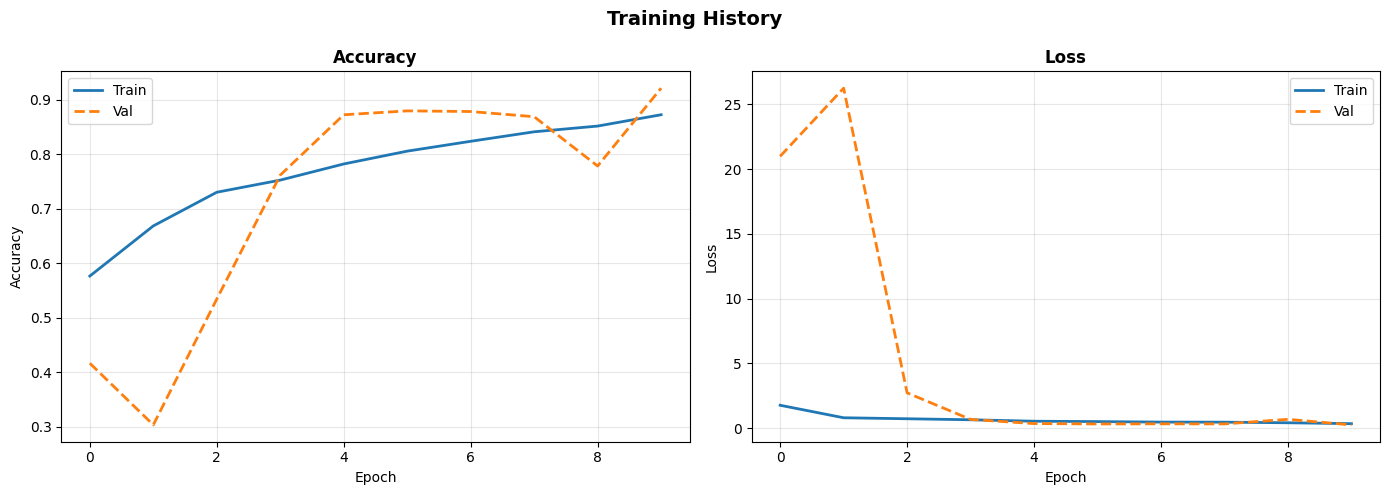

In [ ]:
# Cell 17 — Training History Plot

if not SKIP_TRAINING and 'history' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy', fontsize=12, weight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[1].set_title('Loss', fontsize=12, weight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=14, weight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Model was loaded from Drive — no training history to plot.')

In [ ]:
# Cell 18 — Save Model to Google Drive

if not SKIP_TRAINING:
    model.save(DRIVE_MODEL_PATH)
    print(f'✅ Model saved to Google Drive: {DRIVE_MODEL_PATH}')
    print('   Next run: model will load automatically — no retraining needed!')
else:
    print('Model was loaded from Drive, no need to re-save.')

✅ Model saved to Google Drive: /content/best_brain_tumor_model_claude.keras
   Next run: model will load automatically — no retraining needed!


Test Loss    : 0.8621
Test Accuracy: 0.8500 (85.00%)
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.65      0.76       400
  meningioma       0.77      0.79      0.78       400
     notumor       0.83      0.99      0.91       400
   pituitary       0.89      0.97      0.93       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.84      1600
weighted avg       0.86      0.85      0.84      1600



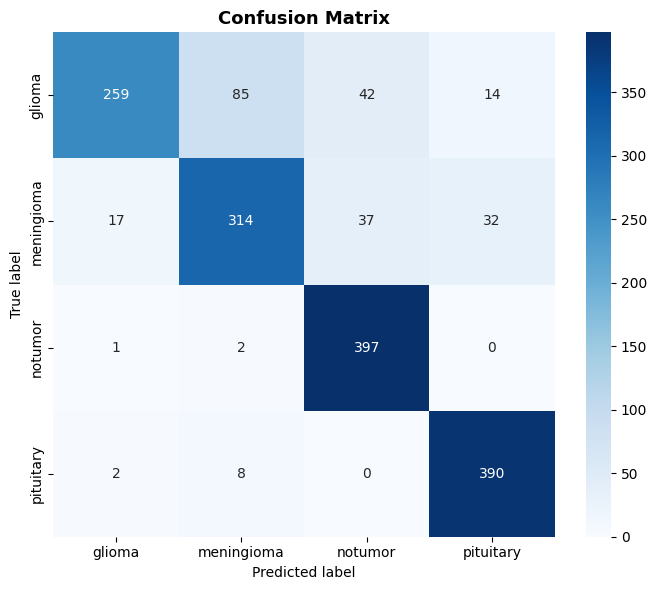

In [ ]:
# Cell 19 — Evaluation

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

y_pred_prob = model.predict(X_test, batch_size=32)
y_pred      = np.argmax(y_pred_prob, axis=1)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix', fontsize=13, weight='bold')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout(); plt.show()


True class: glioma  |  File: Te-gl_204.jpg


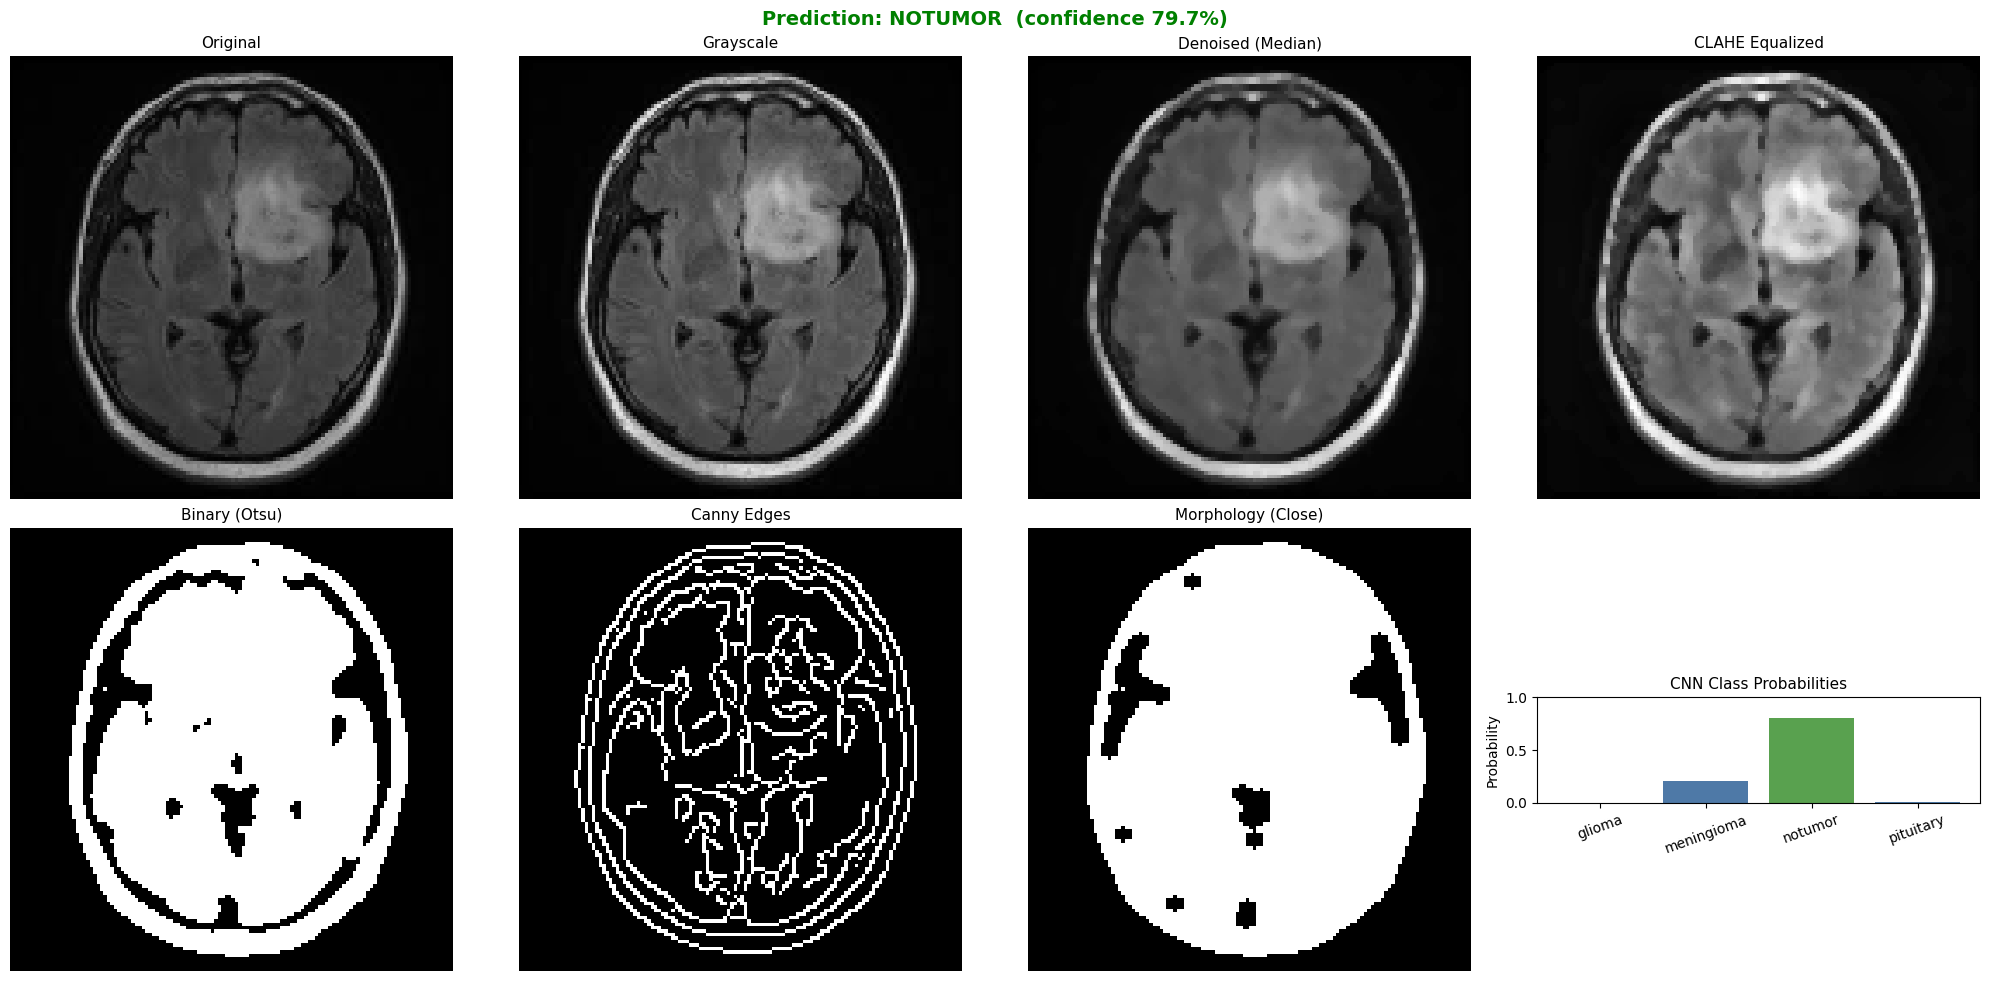

Predicted : notumor  (confidence 79.7%)
All probs : {'glioma': '0.0%', 'meningioma': '20.2%', 'notumor': '79.7%', 'pituitary': '0.1%'}

True class: meningioma  |  File: Te-aug-me_46.jpg


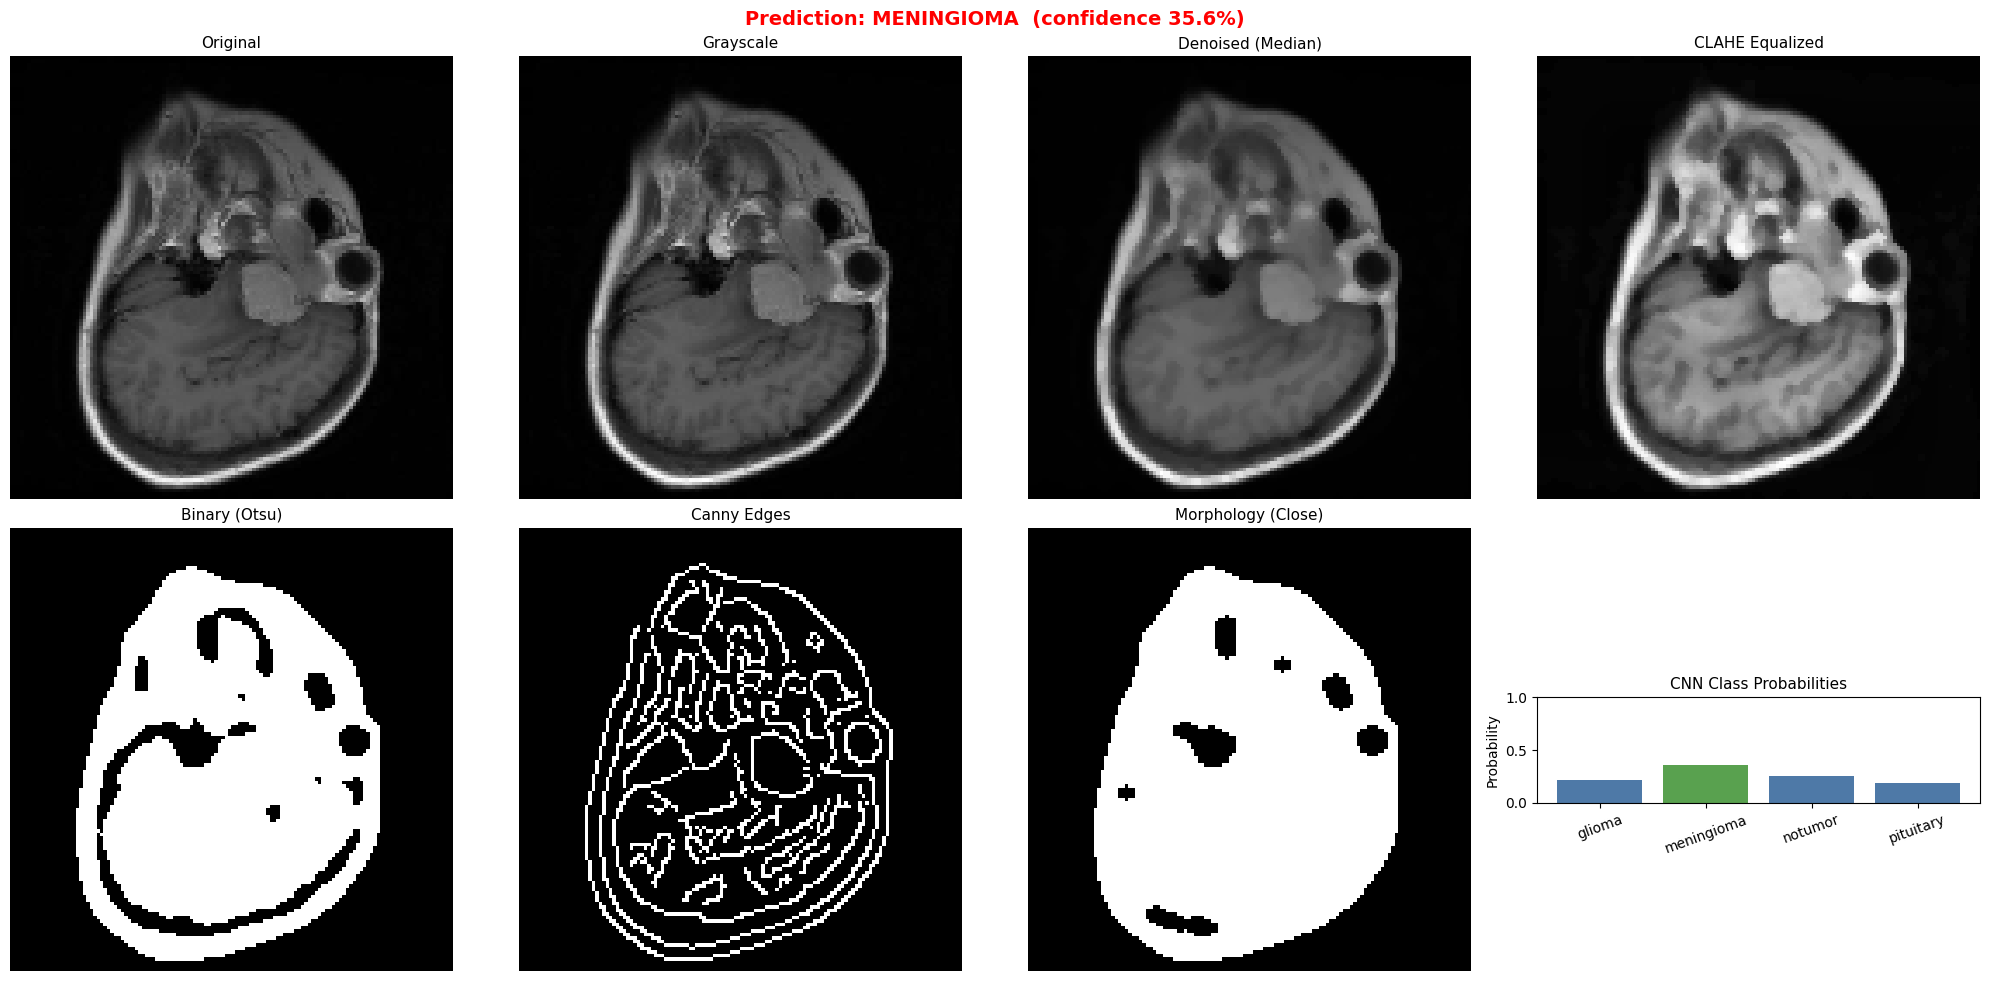

Predicted : meningioma  (confidence 35.6%)
All probs : {'glioma': '20.9%', 'meningioma': '35.6%', 'notumor': '24.8%', 'pituitary': '18.7%'}

True class: notumor  |  File: Te-no_281.jpg


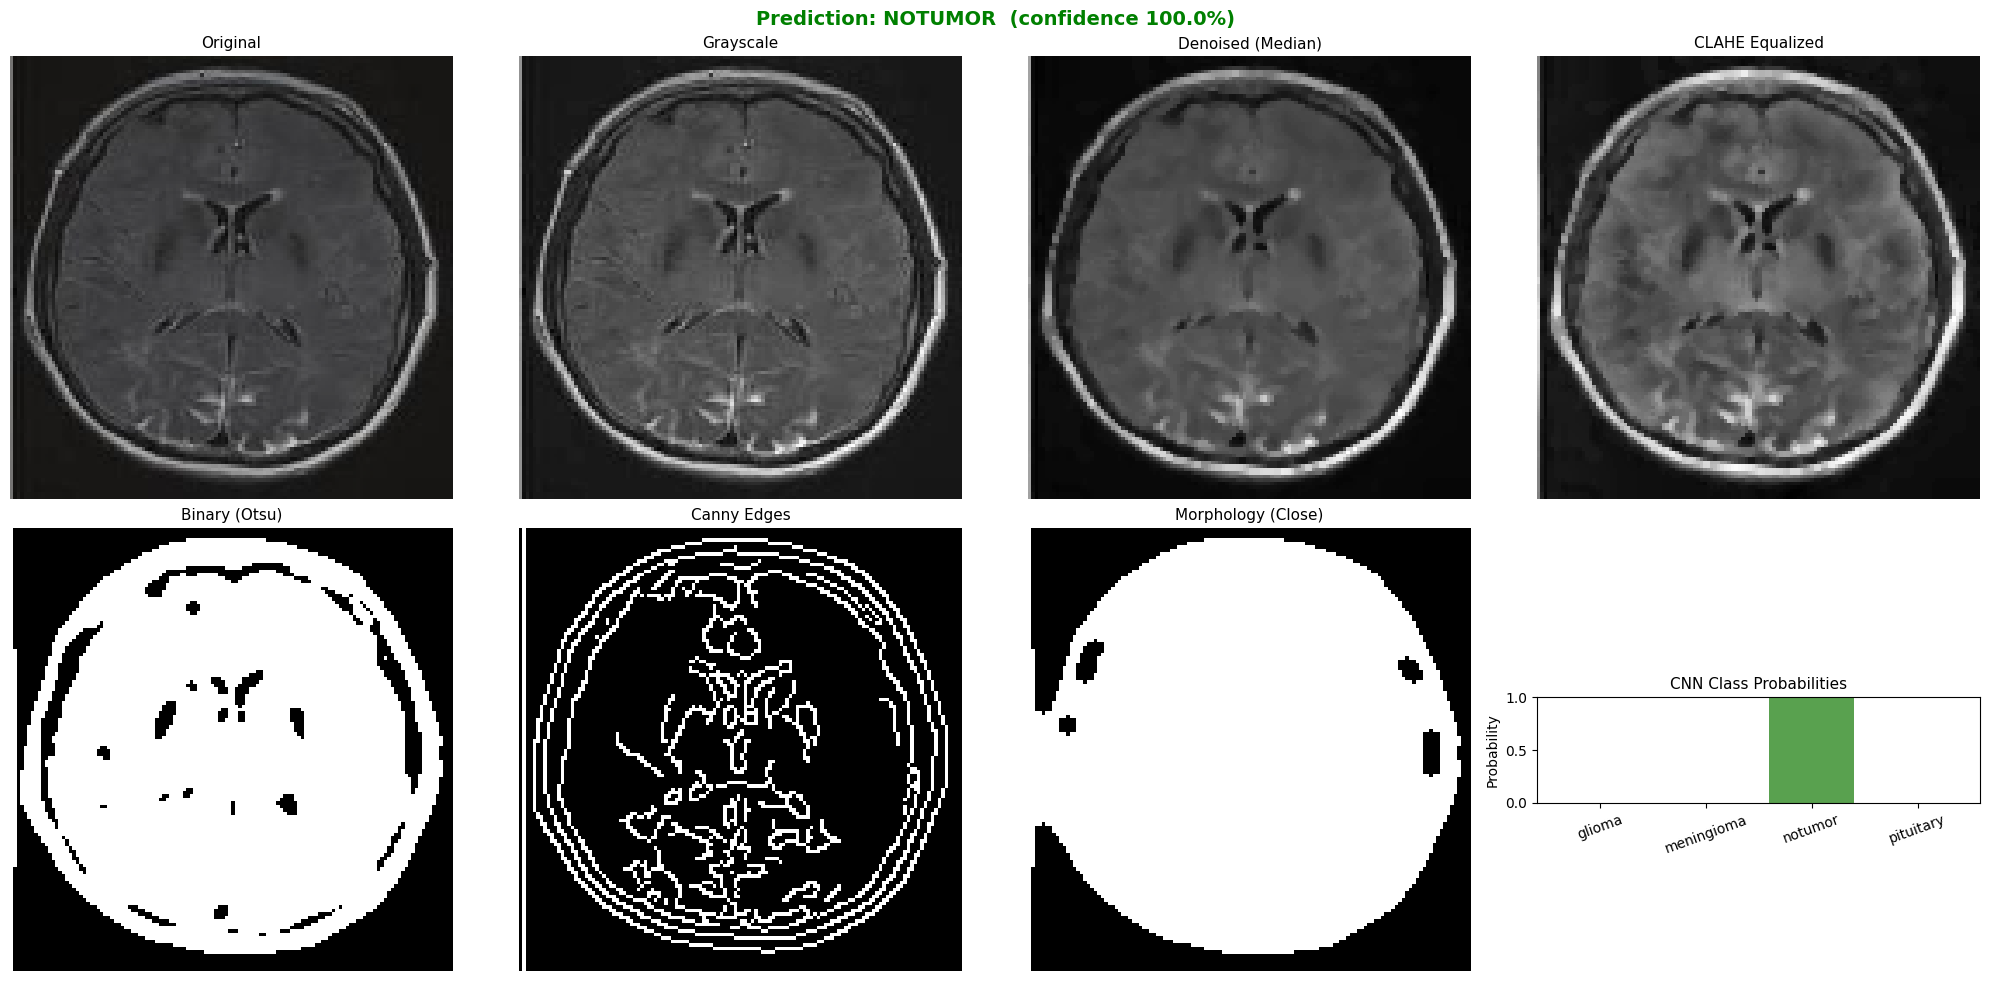

Predicted : notumor  (confidence 100.0%)
All probs : {'glioma': '0.0%', 'meningioma': '0.0%', 'notumor': '100.0%', 'pituitary': '0.0%'}

True class: pituitary  |  File: Te-pi_186.jpg


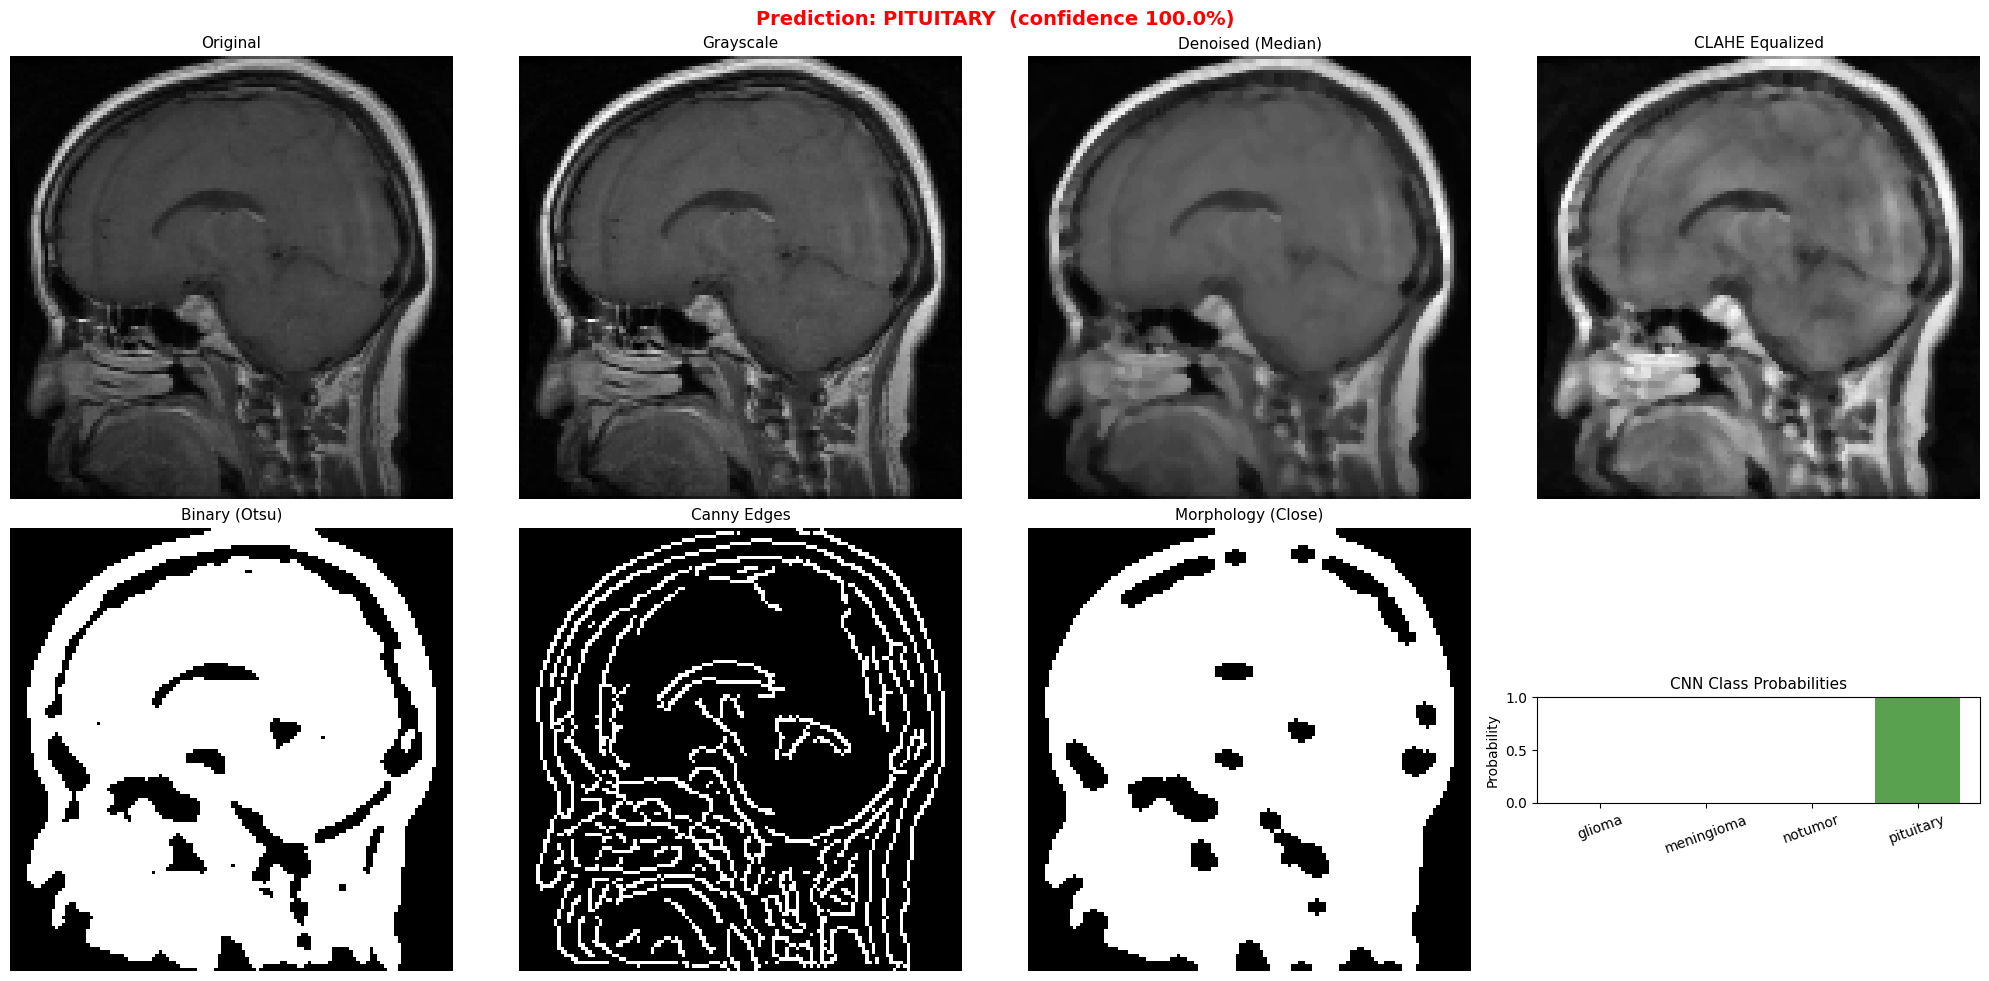

Predicted : pituitary  (confidence 100.0%)
All probs : {'glioma': '0.0%', 'meningioma': '0.0%', 'notumor': '0.0%', 'pituitary': '100.0%'}


In [ ]:
# Cell 20 — Full Pipeline Inference with Stage Visualisation

def full_inference_pipeline(image_path, model, classes=CLASSES, show_plot=True):
    """
    Run the full detection pipeline on one image.
    Shows all processing stages if show_plot=True.
    Returns predicted class and confidence.
    """
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f'Cannot read: {image_path}')

    # ── Stage 1: Grayscale ───────────────────────────────────────────────────
    resized = cv2.resize(bgr, IMG_SIZE)
    gray    = to_grayscale(resized)

    # ── Stage 2: Noise removal ───────────────────────────────────────────────
    denoised = cv2.medianBlur(gray, 3)

    # ── Stage 3: CLAHE ───────────────────────────────────────────────────────
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(denoised)

    # ── Stage 4: Binary ──────────────────────────────────────────────────────
    binary = to_binary_otsu(equalized)

    # ── Stage 5: Edge Detection ──────────────────────────────────────────────
    edges  = edge_detection_canny(equalized)

    # ── Stage 6: Morphology ──────────────────────────────────────────────────
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # ── Stage 7: Region Growing ──────────────────────────────────────────────
    rg_mask  = region_growing(equalized, seed_point=(64, 64), tolerance=20)

    # ── Stage 8: CNN Prediction ──────────────────────────────────────────────
    cnn_input = full_preprocess(bgr)[np.newaxis, ...]    # (1, H, W, 1)
    probs     = model.predict(cnn_input, verbose=0)[0]
    pred_idx  = int(np.argmax(probs))
    pred_cls  = classes[pred_idx]
    confidence = float(probs[pred_idx])

    # ── Visualisation ────────────────────────────────────────────────────────
    if show_plot:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        imgs_and_titles = [
            (cv2.cvtColor(resized, cv2.COLOR_BGR2RGB), 'Original'),
            (gray,      'Grayscale'),
            (denoised,  'Denoised (Median)'),
            (equalized, 'CLAHE Equalized'),
            (binary,    'Binary (Otsu)'),
            (edges,     'Canny Edges'),
            (closed,    'Morphology (Close)'),
            (rg_mask,   'Region Growing'),
        ]
        for ax, (img, ttl) in zip(axes.flat, imgs_and_titles):
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            ax.set_title(ttl, fontsize=11); ax.axis('off')

        # Bar chart of class probabilities
        color = ['#59a14f' if i == pred_idx else '#4e79a7' for i in range(len(classes))]
        axes.flat[-1].cla()
        axes.flat[-1].bar(classes, probs, color=color)
        axes.flat[-1].set_title('CNN Class Probabilities', fontsize=11)
        axes.flat[-1].set_ylim(0, 1); axes.flat[-1].set_ylabel('Probability')
        axes.flat[-1].tick_params(axis='x', rotation=20)
        axes.flat[-1].axis('on')

        result_color = 'red' if pred_cls != 'notumor' else 'green'
        plt.suptitle(
            f'Prediction: {pred_cls.upper()}  (confidence {confidence*100:.1f}%)',
            fontsize=14, weight='bold', color=result_color
        )
        plt.tight_layout(); plt.show()

    return {'class': pred_cls, 'confidence': confidence, 'probabilities': dict(zip(classes, probs.tolist()))}


# ── Run inference on a few random test samples ──────────────────────────────
N_SAMPLES = 2
for cls in CLASSES:
    cls_imgs = list((DATASET_DIR / 'test' / cls).glob('*.jpg'))[:N_SAMPLES]
    if not cls_imgs: continue
    img_path = random.choice(cls_imgs)
    print(f'\n{"="*55}')
    print(f'True class: {cls}  |  File: {img_path.name}')
    result = full_inference_pipeline(img_path, model, show_plot=True)
    print(f'Predicted : {result["class"]}  (confidence {result["confidence"]*100:.1f}%)')
    print('All probs :', {k: f"{v*100:.1f}%" for k, v in result["probabilities"].items()})

Upload an MRI brain scan image (.jpg or .png)...


Saving Te-aug-me_34.jpg to Te-aug-me_34.jpg

Running full pipeline on: Te-aug-me_34.jpg


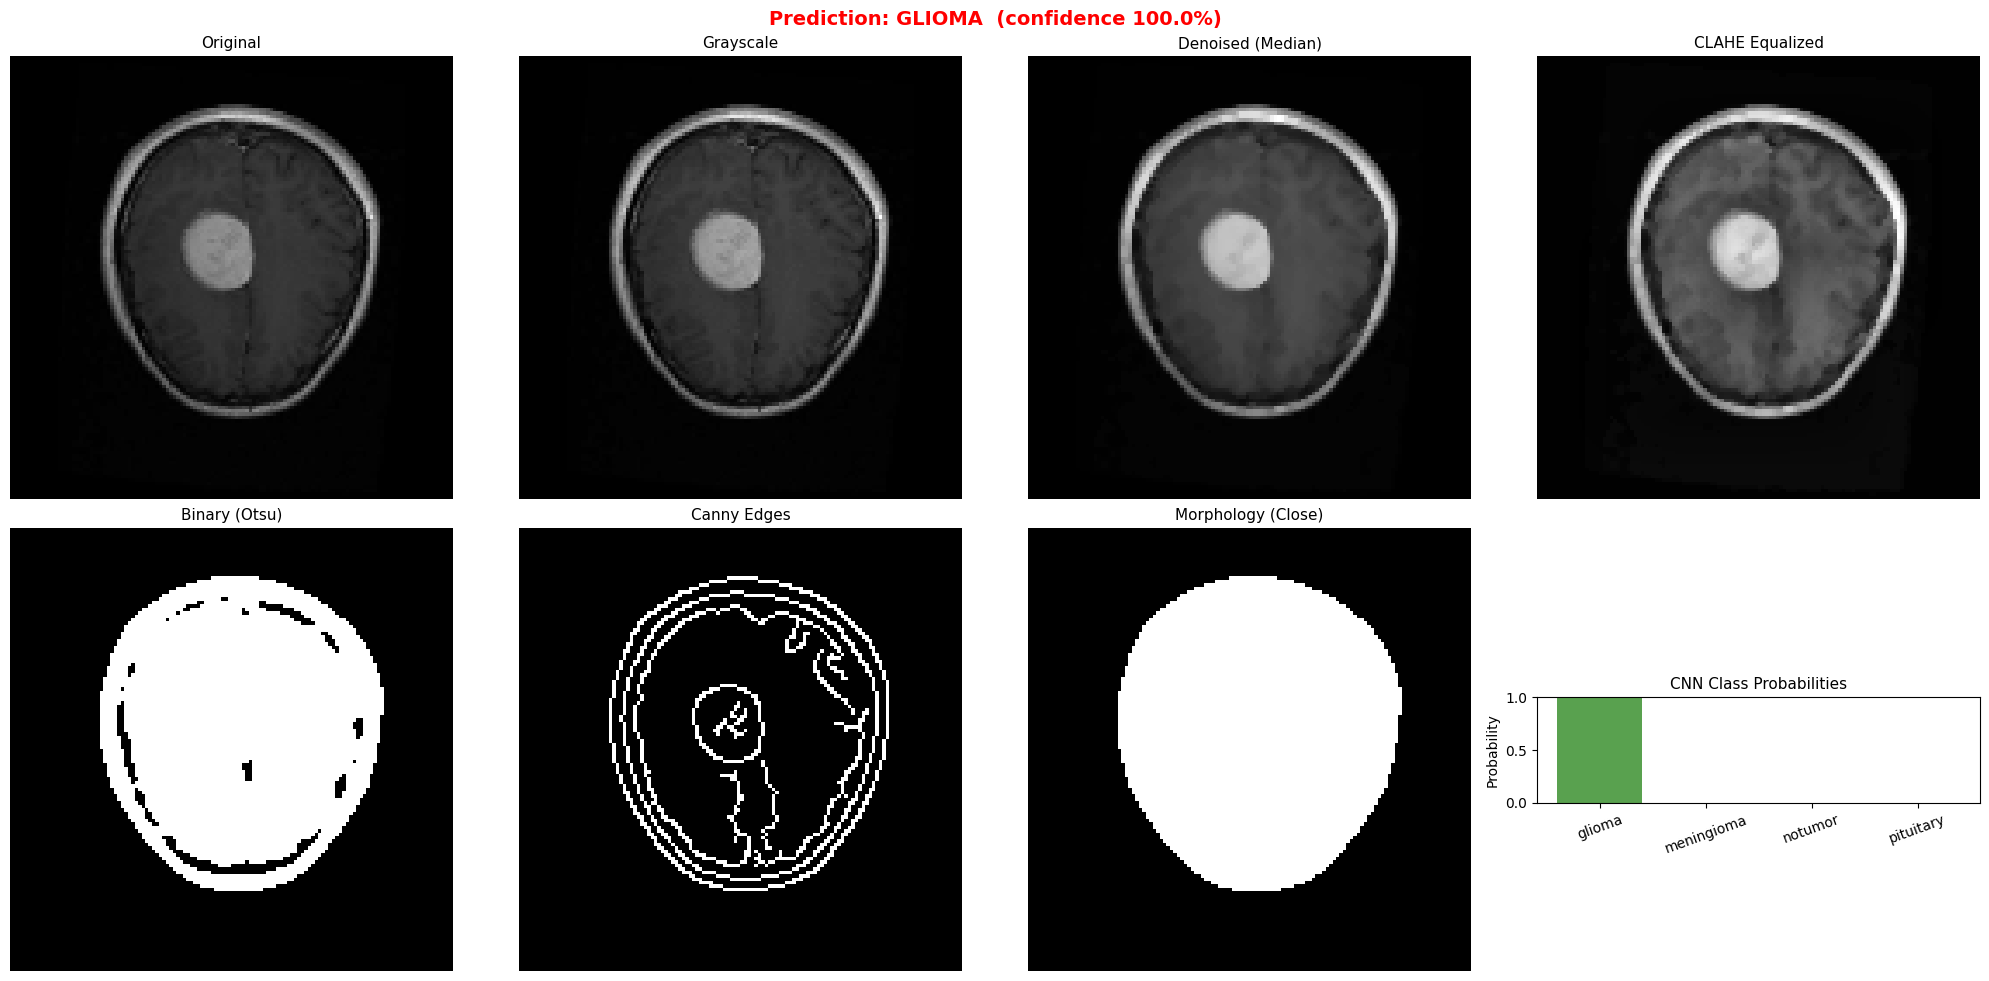


>>> PREDICTION : GLIOMA <<<
>>> CONFIDENCE : 100.00% <<<


In [ ]:
# Cell 21 — Upload and Predict Your Own Image

from google.colab import files as colab_files

print('Upload an MRI brain scan image (.jpg or .png)...')
uploaded = colab_files.upload()

for filename in uploaded:
    print(f'\nRunning full pipeline on: {filename}')
    result = full_inference_pipeline(filename, model, show_plot=True)
    print(f'\n>>> PREDICTION : {result["class"].upper()} <<<')
    print(f'>>> CONFIDENCE : {result["confidence"]*100:.2f}% <<<')

Model saved → /content/best_brain_tumor_model_claude.keras
Training history saved → /content/drive/MyDrive/brain_tumor_outputs/history_20260513_1645.json
Test predictions saved → /content/drive/MyDrive/brain_tumor_outputs/test_predictions_20260513_1645.npy
Classification report saved → /content/drive/MyDrive/brain_tumor_outputs/classification_report_20260513_1645.txt


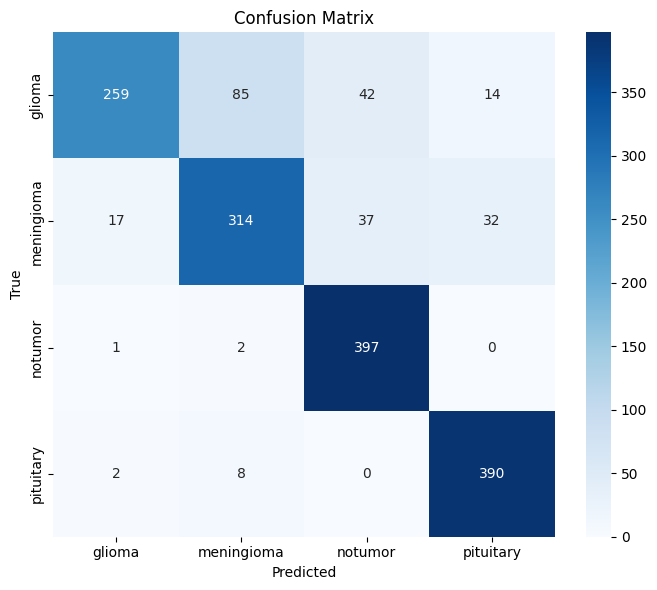

Confusion matrix saved → /content/drive/MyDrive/brain_tumor_outputs/confusion_matrix_20260513_1645.png

✅ All outputs saved to Google Drive!


In [ ]:
# Cell 22 — Save Outputs (History, Predictions, Report) to Drive

import json, datetime

DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/brain_tumor_outputs'
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M')

# 1. Save model
model.save(DRIVE_MODEL_PATH)
print(f'Model saved → {DRIVE_MODEL_PATH}')

# 2. Save training history (if trained this session)
if not SKIP_TRAINING and 'history' in dir():
    hist_path = f'{DRIVE_OUTPUT_DIR}/history_{timestamp}.json'
    with open(hist_path, 'w') as f:
        json.dump({
            k: [float(v) for v in vals]
            for k, vals in history.history.items()
        }, f, indent=2)
    print(f'Training history saved → {hist_path}')

# 3. Save test predictions
pred_path = f'{DRIVE_OUTPUT_DIR}/test_predictions_{timestamp}.npy'
np.save(pred_path, y_pred)
print(f'Test predictions saved → {pred_path}')

# 4. Save classification report as text
report_str = classification_report(y_test, y_pred, target_names=CLASSES)
report_path = f'{DRIVE_OUTPUT_DIR}/classification_report_{timestamp}.txt'
with open(report_path, 'w') as f:
    f.write(f'Brain Tumor Detection — Evaluation Report\n')
    f.write(f'Timestamp: {timestamp}\n')
    f.write(f'Test Accuracy: {test_acc*100:.2f}%\n\n')
    f.write(report_str)
print(f'Classification report saved → {report_path}')

# 5. Save confusion matrix plot
cm_plot_path = f'{DRIVE_OUTPUT_DIR}/confusion_matrix_{timestamp}.png'
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(cm_plot_path, dpi=150)
plt.show()
print(f'Confusion matrix saved → {cm_plot_path}')

print('\n✅ All outputs saved to Google Drive!')